In [1]:
# def makeFullAdder():
#     from qiskit import QuantumCircuit
#     # from qiskit.primitives import StatevectorSampler
#     from qiskit.circuit import QuantumRegister, ClassicalRegister
#     from qiskit.visualization import plot_histogram
#     from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
#     from qiskit.primitives import StatevectorSampler
#     from IPython.display import display
#     sampler = StatevectorSampler()

        
#     #since these operations are from right to left, we iterate backwards:
        
#     # cr = ClassicalRegister(5,"classicalRegister")
#     qr0 = QuantumRegister(1,"Control 1")
#     qr1 = QuantumRegister(1,"Control 2")
#     qr2 = QuantumRegister(1,"A")
#     qr3 = QuantumRegister(1,"B")
#     qr4 = QuantumRegister(1,"Carry_in")
#     qr5 = QuantumRegister(1,"Carry_out")
#     qr6 = QuantumRegister(1,"Sum")
#     qr7 = QuantumRegister(1,"Temp1")
#     qr8 = QuantumRegister(1,"Temp2")
#     qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, name='Full-adder circuit')

#     control_1 = 0
#     control_2 = 1
#     A = 2
#     B = 3
#     Carry_in = 4
#     Carry_out = 5
#     Sum = 6
#     Temp1 = 7
#     Temp2 = 8


#     #set up the SUM of the LSBs (least signigicant bits)
#     #solve the sub(Carry XOR B)
#     # qc.append(CCXGate(), [Carry_in, B, Temp2]) #*********
#     #First XOR (sum):
#     #XOR A4 and B4 to fill T1
#     qc.append(CCXGate(), [control_2,A,Temp1])
#     qc.append(CCXGate(), [control_2,B,Temp1])

#     #Perform XOR between the T1 and the carry to get the sum
#         #Xor with T1
#     qc.append(CCXGate(), [control_2,Temp1,Sum])

#         #Xor with carry ****
#     qc.append(CCXGate(), [control_2,Carry_in,Sum])

#     #Sum between A4 and B4 is done



#     #Carry for A4 and B4
#         #AND between T1 and C-IN dumped into T2 ****
#     qc.append(CCXGate(),[Carry_in,Temp1,Temp2])


#         #now we clean T1 from the A4 XOR B4 operation
#     qc.append(CCXGate(), [control_2,B,Temp1])
#     qc.append(CCXGate(), [control_2,A,Temp1])

#         #AND between A4 and B4 into T1
#     qc.append(CCXGate(),[A,B,Temp1])

#     #OR T1 and T2:
#         #First, Not(T2)
#     qc.append(CCXGate(), [control_1,control_2,Temp2])
#         #Second, Not(T1)
#     qc.append(CCXGate(), [control_1, control_2, Temp1])
#     #And both T1 and T2 into carry bit 2 
#     qc.append(CCXGate(), [Temp1, Temp2, Carry_out])
#     #Finally, invert carry bit
#     qc.append(CCXGate(), [control_1, control_2, Carry_out])

#     #Or finished and Carry computed, clean T1 and T2
#     # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

#     #reverse the NOT and AND
#         #the NOT
#     qc.append(CCXGate(), [control_1, control_2, Temp1])

#         #the and
#     qc.append(CCXGate(), [A, B, Temp1])

#     #T1 should be back into its OG state, so now we recompute A XOR B
#     qc.append(CCXGate(), [control_2,A,Temp1])
#     qc.append(CCXGate(), [control_2,B,Temp1])

#     #undo NOT T2
#     qc.append(CCXGate(), [control_1,control_2,Temp2])

#     #UNDO T1 AND C_In
#     qc.append(CCXGate(),[Carry_in,Temp1,Temp2])

#     #T2 is now back to its og state, now clean T1 again
#     qc.append(CCXGate(), [control_2,B,Temp1])
#     qc.append(CCXGate(), [control_2,A,Temp1])

#     adder_qc = qc.to_gate(label="Full adder")
#     return adder_qc

#     #Now repeat for all qbits


In [ ]:
def FourBitQuantumAdderSubstractor(number1 = None, number2 = None, mode = "add"):

    from qiskit import QuantumCircuit
    from CircuitMakingFunctions import makeFullAdder
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    sampler = StatevectorSampler()

    if(mode != "add" and mode != "sub"):
        print(mode)
        print("Wrong mode. It must be either 'add' or 'sub'")
        return None
        #since these operations are from right to left, we iterate backwards:
        
    cr = ClassicalRegister(5,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    qr2 = QuantumRegister(1,"A1")
    qr3 = QuantumRegister(1,"A2")
    qr4 = QuantumRegister(1,"A3")
    qr5 = QuantumRegister(1,"A4")
    qr6 = QuantumRegister(1,"B1")
    qr7 = QuantumRegister(1,"B2")
    qr8 = QuantumRegister(1,"B3")
    qr9 = QuantumRegister(1,"B4")
    qr10 = QuantumRegister(1,"Carry1")
    qr11 = QuantumRegister(1,"Carry2")
    qr12 = QuantumRegister(1,"Carry3")
    qr13 = QuantumRegister(1,"Carry4")
    qr14 = QuantumRegister(1,"Carry5")
    qr15 = QuantumRegister(1,"Sum1")
    qr16 = QuantumRegister(1,"Sum2")
    qr17 = QuantumRegister(1,"Sum3")
    qr18 = QuantumRegister(1,"Sum4")
    qr19 = QuantumRegister(1,"Temp1")
    qr20 = QuantumRegister(1,"Temp2")
    qr21 = QuantumRegister(1,"Temp3")
    qr22 = QuantumRegister(1,"Sub?")
    # qr23 = QuantumRegister(1,"Two's carry")

    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, qr12, qr13, qr14, qr15, qr16, qr17, qr18, qr19, qr20, qr21, qr22, cr, name='Full-adder circuit')

    control_1 = 0
    control_2 = 1
    A1 = 2
    A2 = 3
    A3 = 4
    A4 = 5
    B1 = 6
    B2 = 7
    B3 = 8
    B4 = 9
    Carry1 = 10
    Carry2 = 11
    Carry3 = 12
    Carry4 = 13
    Carry5 = 14
    Sum1 = 15
    Sum2 = 16
    Sum3 = 17
    Sum4 = 18
    Temp1 = 19
    Temp2 = 20
    Temp3 = 21
    Sub = 22
    # TwosCarry = 23
    # negFlag
    if(number1 != None and number2 != None):
        if((number1 < 0 or number1 > 15 or number2 < 0 or number2 > 15)):
            print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
            return False
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        count = 2
        if(len(binary1) != 4):
            length = 4 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 4):
            length = 4 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        # print(f"first operand {binary1} and second operand {binary2}\n")
    
    #read the input and set the 
    #appropiate qbits to |1>

        for x in range(0,4):
            if(binary1[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1
    else:
        count = 2
        for x in range(0,4):
            qc.append(HGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            qc.append(HGate(), [count])
            count += 1
    if(mode == "sub"):
        qc.append(XGate(), [Sub])
        qc.append(XGate(), [Carry1])

    #set the control bit to |1>
    qc.append(XGate(), [control_1])
    qc.append(XGate(), [control_2])


    full_adder = makeFullAdder()
    qc.append(full_adder, [control_1, control_2, A4, B4, Carry1, Carry2, Sum1, Temp1, Temp2, Temp3, Sub ])
    qc.append(full_adder, [control_1, control_2, A3, B3, Carry2, Carry3, Sum2, Temp1, Temp2, Temp3, Sub ])
    qc.append(full_adder, [control_1, control_2, A2, B2, Carry3, Carry4, Sum3, Temp1, Temp2, Temp3, Sub ])
    qc.append(full_adder, [control_1, control_2, A1, B1, Carry4, Carry5, Sum4, Temp1, Temp2, Temp3, Sub ])


    # #now we can meassure carry and Sum
    
    #carry
    qc.measure(Carry5,4)
    # #and sum

    qc.measure(Sum4, 3)
    qc.measure(Sum3, 2)
    qc.measure(Sum2, 1)
    qc.measure(Sum1, 0)
    

   #COMMENT THIS MARKED SECTION WHEN USING THE TESTS AND METRICS FUNCTION --------------------------------------
    # display(qc.draw("mpl"))
    samplerSim = StatevectorSampler()
    result = samplerSim.run([qc], shots=(1024*4)).result()
    counts = result[0].data.classicalRegister.get_counts()
    pretty_counts = {}
    # res = 0
    for bitstring, count in counts.items():
        carry = bitstring[0]
        sum_bits = bitstring[1:]

        label = f"carry={carry}, sum/sub={sum_bits}"
        pretty_counts[label] = count
        if(number1 != None and number2 != None):
            if(mode == "add"):
                print(bitstring, "→",
                    "carry =",     bitstring[0],
                    "sum bits =", bitstring[1:],
                    "Result =", int(bitstring, 2))
                # res = int(bitstring, 2)
            else:
                print(bitstring, "→",
                    "carry =",     bitstring[0],
                    "sub bits =", bitstring[1:],
                    "Result =", int(bitstring[1:], 2))
        res = bitstring
    # if(carry == "0"):
    #     print("we need two's comp.")

    # display(plot_histogram(pretty_counts, title=mode))
   #-----------------------------------------------------------------------------------------------





    return qc
    # return res




In [ ]:

print("Expected: 5")
FourBitQSubstractor = FourBitQuantumAdderSubstractor(9,14,mode ="sub")
# print("\n")
FourBitQSubstractor = FourBitQuantumAdderSubstractor(14,9,mode ="sub")

# print("\n")

# print("Expected: 7")

# FourBitQSubstractor = FourBitQuantumAdderSubstractor(8,15,mode ="sub")
# print("\n")
# FourBitQSubstractor = FourBitQuantumAdderSubstractor(15,8,mode ="sub")

# from Quantum_Circuit_Tests_and_metrics import runQCTests_and_metrics
# runQCTests_and_metrics(FourBitQAdder, "add", "Distribution of simulated 4-bit Q-adder vs Experimental 4-bit Q-Adder")

# print("\n\n")
# runQCTests_and_metrics(FourBitQSubstractor, "sub", "Distribution of simulated 4-bit Q-Substractor vs Experimental 4-bit Q-Substractor")

# for i in range(1,16):
#     for j in range(16):
#         result = FourBitQuantumAdderSubstractor(i,j)
#         expected = i + j
#         if(result != expected):
#             print(f"Test failed for {i} + {j}. Expected {expected} but got {result}")
#             break
#     if(result != expected):
#         break


Expected: 7
01011 → carry = 0 sub bits = 1011 Result = 11
10101 → carry = 1 sub bits = 0101 Result = 5


In [57]:
def TwoBitQuantumAdderSubstractor(number1 = None, number2 = None, mode = "add"):

    from qiskit import QuantumCircuit
    from CircuitMakingFunctions import makeFullAdder
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    sampler = StatevectorSampler()

    if(mode != "add" and mode != "sub"):
        print(mode)
        print("Wrong mode. It must be either 'add' or 'sub'")
        return None
        #since these operations are from right to left, we iterate backwards:
        
    cr = ClassicalRegister(3,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    # qr2 = QuantumRegister(1,"A1")
    # qr3 = QuantumRegister(1,"A2")
    qr4 = QuantumRegister(1,"A3")
    qr5 = QuantumRegister(1,"A4")
    # qr6 = QuantumRegister(1,"B1")
    # qr7 = QuantumRegister(1,"B2")
    qr8 = QuantumRegister(1,"B3")
    qr9 = QuantumRegister(1,"B4")
    qr10 = QuantumRegister(1,"Carry1")
    qr11 = QuantumRegister(1,"Carry2")
    qr12 = QuantumRegister(1,"Carry3")
    # qr13 = QuantumRegister(1,"Carry4")
    # qr14 = QuantumRegister(1,"Carry5")
    qr15 = QuantumRegister(1,"Sum1")
    qr16 = QuantumRegister(1,"Sum2")
    # qr17 = QuantumRegister(1,"Sum3")
    # qr18 = QuantumRegister(1,"Sum4")
    qr19 = QuantumRegister(1,"Temp1")
    qr20 = QuantumRegister(1,"Temp2")
    qr21 = QuantumRegister(1,"Temp3")
    qr22 = QuantumRegister(1,"Sub?")
    # qr23 = QuantumRegister(1,"Two's carry")

    qc = QuantumCircuit(qr0, qr1, qr4, qr5, qr8, qr9, qr10, qr11, qr12,  qr15, qr16, qr19, qr20, qr21, qr22, cr, name='Full-adder/substractor circuit')

    control_1 = 0
    control_2 = 1
    # A1 = 2
    # A2 = 3
    A3 = 2
    A4 = 3
    # B1 = 6
    # B2 = 7
    B3 = 4
    B4 = 5
    Carry1 = 6
    Carry2 = 7
    Carry3 = 8
    # Carry4 = 13
    # Carry5 = 14
    Sum1 = 9
    Sum2 = 10
    # Sum3 = 17
    # Sum4 = 18
    Temp1 = 11
    Temp2 = 12
    Temp3 = 13
    Sub = 14
    # TwosCarry = 23
    # negFlag
    if(number1 != None and number2 != None):
        if((number1 < 0 or number1 > 15 or number2 < 0 or number2 > 15)):
            print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
            return False
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]

        if(len(binary1) != 2):
            length = 2 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 2):
            length = 2 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        # print(f"first operand {binary1} and second operand {binary2}\n")
    
    #read the input and set the 
    #appropiate qbits to |1>
        count = 2
        for x in range(0,2):
            # print(binary1[x])
            if(binary1[x] == "1"):

                qc.append(XGate(), [count])
            count += 1

        count = 4
        for x in range(0,2):
            # print(binary2[x])
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1
    else:
        count = 4
        for x in range(0,2):
            qc.append(HGate(), [count])
            count += 1

        count = 8
        for x in range(0,2):
            qc.append(HGate(), [count])
            count += 1
    if(mode == "sub"):
        qc.append(XGate(), [Sub])
        qc.append(XGate(), [Carry1])

    #set the control bit to |1>
    qc.append(XGate(), [control_1])
    qc.append(XGate(), [control_2])


    full_adder = makeFullAdder()
    qc.append(full_adder, [control_1, control_2, A4, B4, Carry1, Carry2, Sum1, Temp1, Temp2, Temp3, Sub ])
    qc.append(full_adder, [control_1, control_2, A3, B3, Carry2, Carry3, Sum2, Temp1, Temp2, Temp3, Sub ])
    # qc.append(full_adder, [control_1, control_2, A2, B2, Carry3, Carry4, Sum3, Temp1, Temp2, Temp3, Sub ])
    # qc.append(full_adder, [control_1, control_2, A1, B1, Carry4, Carry5, Sum4, Temp1, Temp2, Temp3, Sub ])


    # #now we can meassure carry and Sum
    
    #carry
    qc.measure(Carry3,2)
    # #and sum

    # qc.measure(Sum4, 3)
    # qc.measure(Sum3, 2)
    qc.measure(Sum2, 1)
    qc.measure(Sum1, 0)
    

   #COMMENT THIS MARKED SECTION WHEN USING THE TESTS AND METRICS FUNCTION --------------------------------------
    # display(qc.draw("mpl"))
    # samplerSim = StatevectorSampler()
    # result = samplerSim.run([qc], shots=(1024*4)).result()
    # counts = result[0].data.classicalRegister.get_counts()
    # pretty_counts = {}
    # # res = 0
    # for bitstring, count in counts.items():
    #     carry = bitstring[0]
    #     sum_bits = bitstring[1:]

    #     label = f"carry={carry}, sum/sub={sum_bits}"
    #     pretty_counts[label] = count
    #     if(number1 != None and number2 != None):
    #         if(mode == "add"):
    #             print(bitstring, "→",
    #                 "carry =",     bitstring[0],
    #                 "sum bits =", bitstring[1:],
    #                 "Result =", int(bitstring, 2))
    #             # res = int(bitstring, 2)
    #         else:
    #             print(bitstring, "→",
    #                 "carry =",     bitstring[0],
    #                 "sub bits =", bitstring[1:],
    #                 "Result =", int(bitstring[1:], 2))
    #     res = bitstring
    # # if(carry == "0"):
    # #     print("we need two's comp.")

    # display(plot_histogram(pretty_counts, title=mode))
    # display(qc.draw('mpl'))
   #-----------------------------------------------------------------------------------------------





    return qc
    # return res




Expected: 1
Quantum circuit being evaluated:  


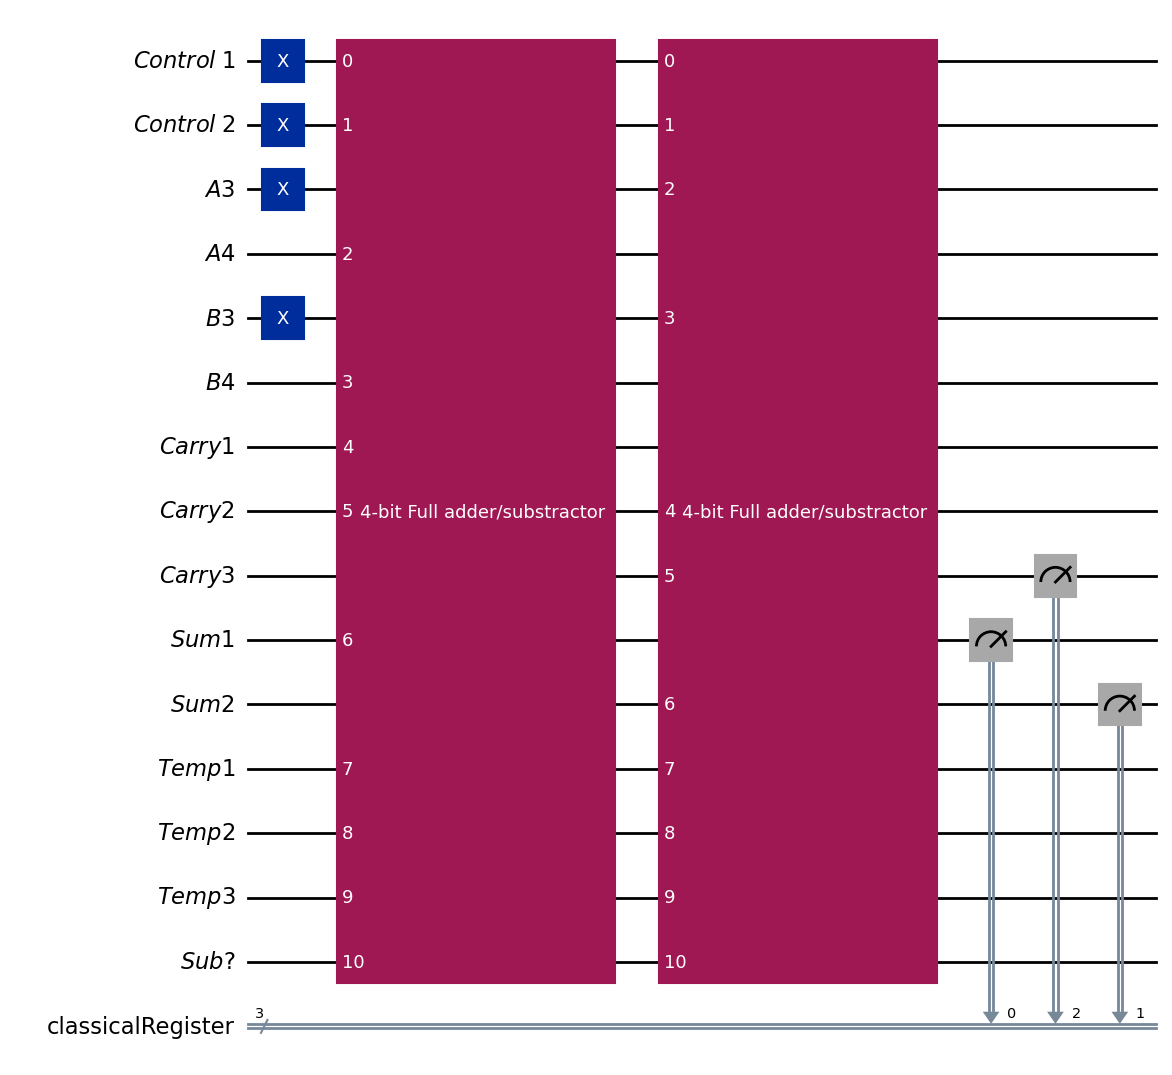

IBMInputValueError: 'The given API token is associated with an account that does not have access to the instance crn:v1:bluemix:public:quantum-computing:us-east:a/d34f89567a9c4dacb66d58f0af4a7830:4dc3dd51-369b-4323-a616-2871e801a9d3::. To use this instance, use an API token generated from the account with this instance available.'

In [ ]:
# print("Expected: 1")
twoBitQAdder = TwoBitQuantumAdderSubstractor(2,2,mode ="add")
twoBitQAdderDist = TwoBitQuantumAdderSubstractor(mode ="add")

twoBitQSubstractor = TwoBitQuantumAdderSubstractor(2,1,mode ="sub")
twoBitQSubstractorDist = TwoBitQuantumAdderSubstractor(mode ="sub")
# print("\n")
# twoBitQSubstractor2 = TwoBitQuantumAdderSubstractor(1,1,mode ="add")

# print(f"{twoBitQSubstractor1} first val\n{twoBitQSubstractor2}")

from Quantum_Circuit_Tests_and_metrics import runQCTests_and_metrics
runQCTests_and_metrics(twoBitQAdder, "add", "Distribution of simulated 4-bit Q-adder vs Experimental 4-bit Q-Adder")